In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from typing import Optional
import torch.nn.functional as F

from model import Transformer, make_src_mask, make_tgt_mask

from tqdm import tqdm

from config import *

from dataset_cfd import *
from lr_scheduler import *
from train import *

import numpy as np
import matplotlib.pyplot as plt

import json
import os

In [2]:
config = {
        "grid_size"        : 64,
        "patch_size"       : 8,
        "patch_dim"        : 8*8*2 + (4 * 16),
        "d_model"          : 512,
        "N"                : 6,
        "num_heads"        : 8,
        "d_ff"             : 1024,
        "dropout"          : 0.01,
        "train_batch_size" : 8,
        "test_batch_size"  : 8,
        "epochs"           : 500,
        "device"           : 'cuda' if torch.cuda.is_available() else 'cpu',
        "save_every"       : 20
    }

transformer = Transformer(
                        d_model        = config["d_model"],
                        N              = config["N"],
                        num_heads      = config["num_heads"],
                        d_ff           = config["d_ff"],
                        patch_dim      = config['patch_dim'])

In [5]:
load_checkpoint("checkpoint_with_P.pt", transformer)

499

In [8]:
sum(p.numel() for p in transformer.parameters())

35421376

In [60]:
def fourier_features(cords: torch.tensor, num_freq = 16):
    # [num_patches, 2] -> [num_patches, C * num_freq * 2]
    freqs = 2 ** torch.linspace(0, num_freq - 1, num_freq)                   # [num_freqs]
    angles = (cords.unsqueeze(-1) * freqs * 2 * torch.pi)                    # [num_patches, C, num_freq]
    encoded = torch.cat([torch.sin(angles), torch.cos(angles)], dim = -1)    # [num_patches, C, num_freq * 2]
    return encoded.view(cords.shape[0], -1)                                  # [num_patches, C * num_freq * 2]


patches_per_side = config["grid_size"] // config["patch_size"]
coords = []
for row in range(patches_per_side):
    for col in range(patches_per_side):
        coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
coords_tensor = torch.tensor(coords, dtype=torch.float32)


# coords_tensor = fourier_features(coords_tensor)
# coords_tensor.shape


In [ ]:
coords_tensor[:]

In [ ]:
with open("train_test_re.json", "r", encoding="utf-8") as file:
    train_test_re = json.load(file)

In [ ]:
pre_train_re  = sorted([float(i.split('.csv')[0].split("Re_")[-1]) for i in os.listdir("Data_with_P")])
post_train_re = sorted(train_test_re['test_re'] + train_test_re['train_re'])
pre_train_re

In [165]:
def patches_to_contour(patch, num_patches, patch_size, grid_size):

    unrolled = patch.view(num_patches, num_patches, 2, patch_size, patch_size)   # (patch_row, patch_col, C, patch_h, patch_w)
    unrolled = unrolled.permute(2, 0, 3, 1, 4).contiguous()                      # (C, patch_row, patch_h, patch_col, patch_w)
    unrolled = unrolled.view(2, grid_size, grid_size)                            # (2, grid_size, grid_size)

    return unrolled

def predict(re_value, model, re_mean, re_std, u_mean, u_std, v_mean, v_std, config, device="cpu", plot: bool = True):
    # normalize using dataset stats
    re_norm = (re_value - re_mean) / re_std
    src = torch.tensor([[re_norm]], dtype=torch.float32).to(device)  # (1, 1)

    patches_per_side = config["grid_size"] // config["patch_size"]
    coords = []
    for row in range(patches_per_side):
        for col in range(patches_per_side):
            coords.append([(col+0.5)/patches_per_side, (row+0.5)/patches_per_side])
    coords_tensor = torch.tensor(coords, dtype=torch.float32)


    coords_tensor = fourier_features(coords_tensor)

    # decode
    src_mask = make_src_mask(src, -1)
    pred_patches = greedy_decode(
        model, src, src_mask,
        max_len  = (config["grid_size"] // config["patch_size"])**2,
        patch_dim = config["patch_dim"] - (4 * 16), coords_tensor=coords_tensor,
        device   = device, num_freq = 16
    )  # (1, num_patches, patch_dim)

    # pred_patches = pred_patches[:, :, :-2]

    # unroll patches to (2, 64, 64)
    unrolled = patches_to_contour(pred_patches[0],
                                   config["grid_size"] // config["patch_size"],
                                   config["patch_size"],
                                   config["grid_size"])


    u = unrolled[0].detach().cpu()
    v = unrolled[1].detach().cpu()



    # denormalize
    u = (u * u_std) + u_mean
    v = (v * v_std) + v_mean

    # numerical gradients
    u_np = u
    v_np = v
    du_dx = np.gradient(u_np, axis=1)  # derivative along x (cols)
    dv_dy = np.gradient(v_np, axis=0)  # derivative along y (rows)

    divergence = du_dx + dv_dy

    mag = np.sqrt(u**2 + v**2)

    if plot:
        # u = sharpen_field(u.detach().cpu().numpy(), "bilateral")
        # v = sharpen_field(v.detach().cpu().numpy(), "bilateral")

        # plot
        x_grid = np.linspace(0, 1, config["grid_size"])
        y_grid = np.linspace(0, 1, config["grid_size"])

        

        fig, axes = plt.subplots(1, 4, figsize=(20, 5))

        c0 = axes[0].contourf(x_grid, y_grid, u, levels=50, cmap="jet")
        fig.colorbar(c0, ax=axes[0])
        axes[0].set_title("u (m/s)")

        c1 = axes[1].contourf(x_grid, y_grid, v, levels=50, cmap="jet")
        fig.colorbar(c1, ax=axes[1])
        axes[1].set_title("v (m/s)")

        c2 = axes[2].contourf(x_grid, y_grid, mag, levels=50, cmap="jet")
        fig.colorbar(c2, ax=axes[2])
        # axes[2].streamplot(x_grid, y_grid, u, v, color="white", density=1.2)

        axes[2].set_title("|U| + streamlines")


        c3 = axes[3].contourf(divergence, levels=50, cmap="RdBu")
        fig.colorbar(c3, ax=axes[3], label="∇·u")
        axes[3].set_title(f"divergence mean: {divergence.mean():.2f}")

        plt.suptitle(f"Re = {re_value}")
        plt.tight_layout()
        plt.show()

    return u, v, divergence, mag


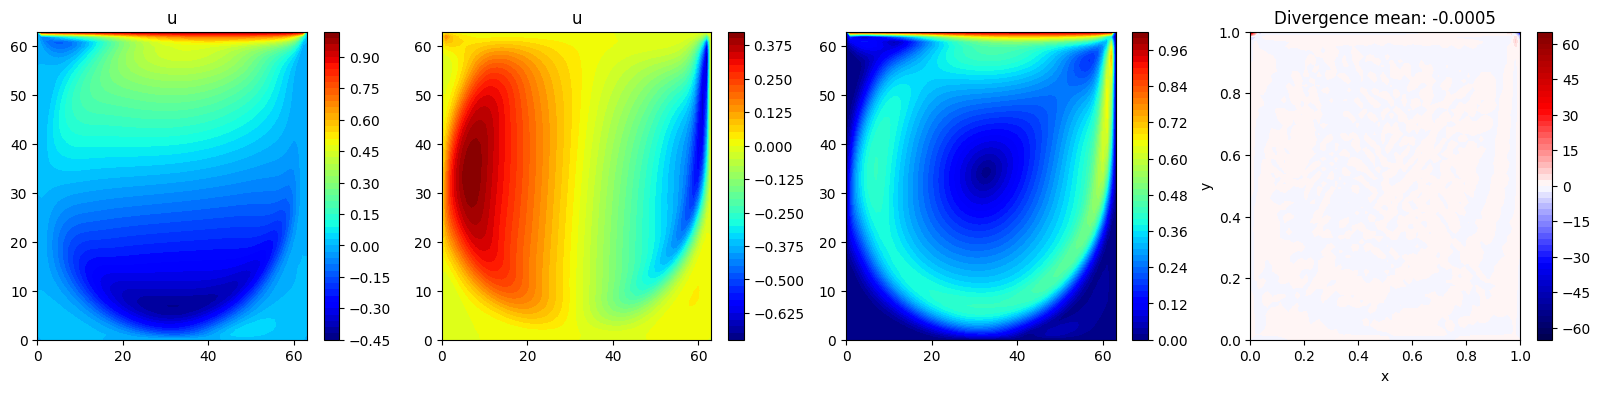

In [168]:
def ground_truth(re: float, plot: bool):

    assert f"Re_{re}.csv" in os.listdir("Data_with_P"), "make sure re is in the csv folder"

    df = pd.read_csv(f"Data_with_P/Re_{re}.csv", index_col = 0)

    lin = np.linspace(0, 1, 64)

    x = df['x']
    y = df['y']
    u = df["u (m/s)"].values.astype(np.float32)
    v = df["v (m/s)"].values.astype(np.float32)

    points = np.stack([x, y], axis=1)  # (N, 2)
    # interpolate u and v onto regular grid

    grid_x, grid_y = np.meshgrid(lin, lin) # (grid_size, grid_size)


    u_grid = griddata(points, u, (grid_x, grid_y), method="linear", fill_value=0.0)
    v_grid = griddata(points, v, (grid_x, grid_y), method="linear", fill_value=0.0)

    dx = lin[1] - lin[0]
    dy = lin[1] - lin[0]

    # gradients
    du_dx = np.gradient(u_grid, dx, axis=1)
    dv_dy = np.gradient(v_grid, dy, axis=0)

    # divergence
    div = du_dx + dv_dy

    mag = np.sqrt(u_grid**2 + v_grid**2)
    
    if plot:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))

        u_c = axes[0].contourf(u_grid, levels=50, cmap="jet")
        plt.colorbar(u_c, ax=axes[0])
        axes[0].set_title("u")

        v_c = axes[1].contourf(v_grid, levels=50, cmap="jet")
        plt.colorbar(v_c, ax=axes[1])
        axes[1].set_title("u")

        
        mag_c = axes[2].contourf(mag, levels=50, cmap="jet")

        plt.colorbar(mag_c, ax=axes[2])

        
        div_c = axes[3].contourf(grid_x, grid_y, div, levels=50, cmap="seismic")
        plt.colorbar(div_c, ax=axes[3])
        axes[3].set_title(f"Divergence mean: {div.mean():.4f}")
        axes[3].set_xlabel("x")
        axes[3].set_ylabel("y")

        plt.show()
    
    return u_grid, v_grid, div, mag

u_grid, v_grid, div, mag = ground_truth(re = 2499.1, plot=True)

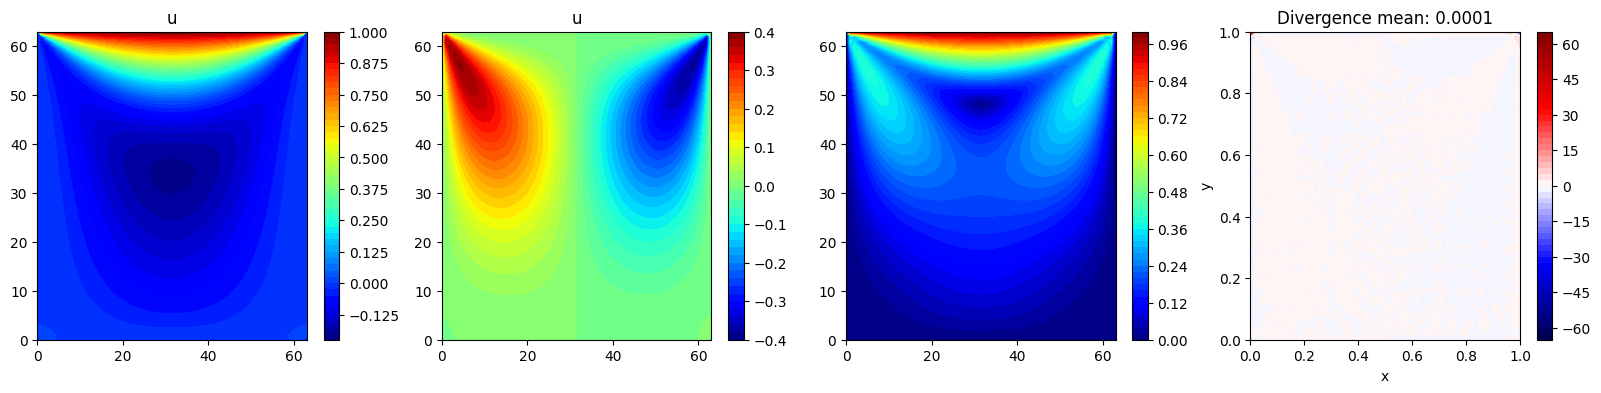

100%|██████████| 64/64 [00:00<00:00, 68.69it/s]


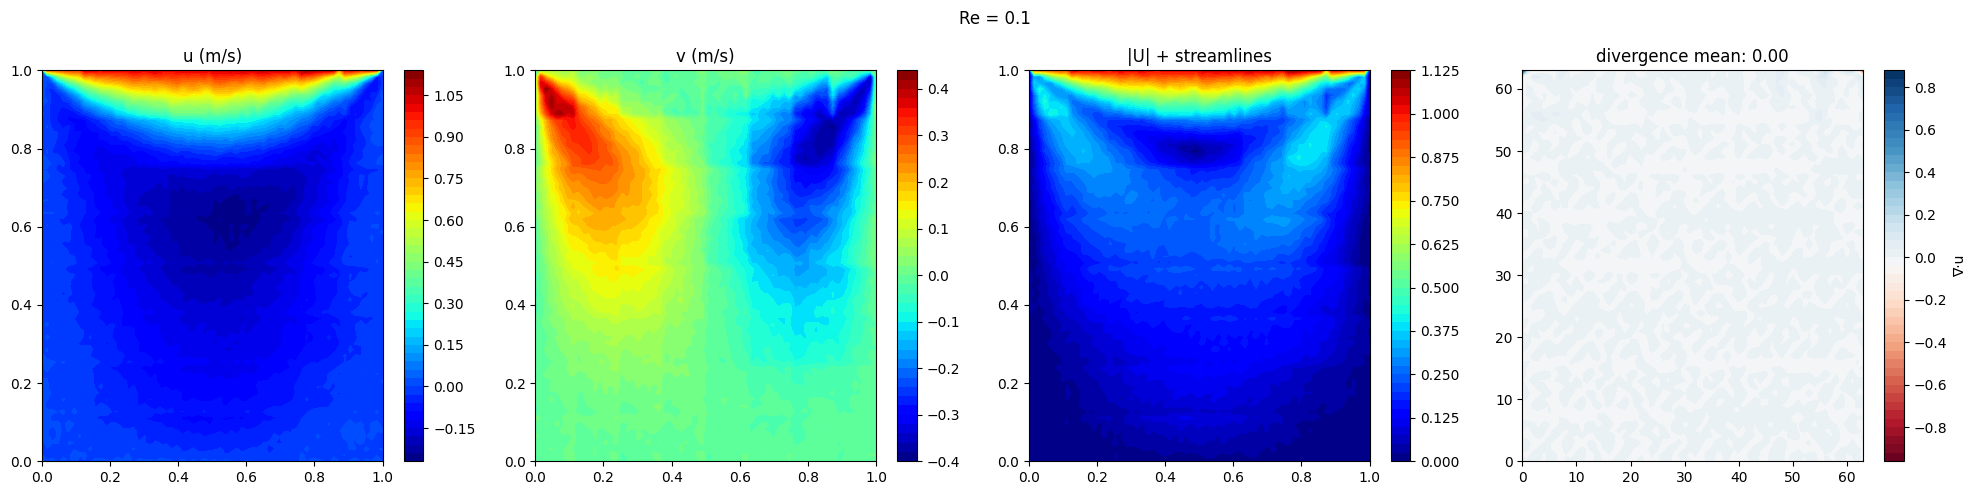

In [169]:
re = 0.1
u_grid_actual, v_grid_actual, div_actual, mag_actual = ground_truth(re = re, plot=True)

u_grid_pred, v_grid_pred, div_pred, mag_pred = predict(re_value = re, model = transformer, 
                                               re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, 
                                               config = config, device = "cpu", plot = True)

100%|██████████| 64/64 [00:00<00:00, 72.58it/s]


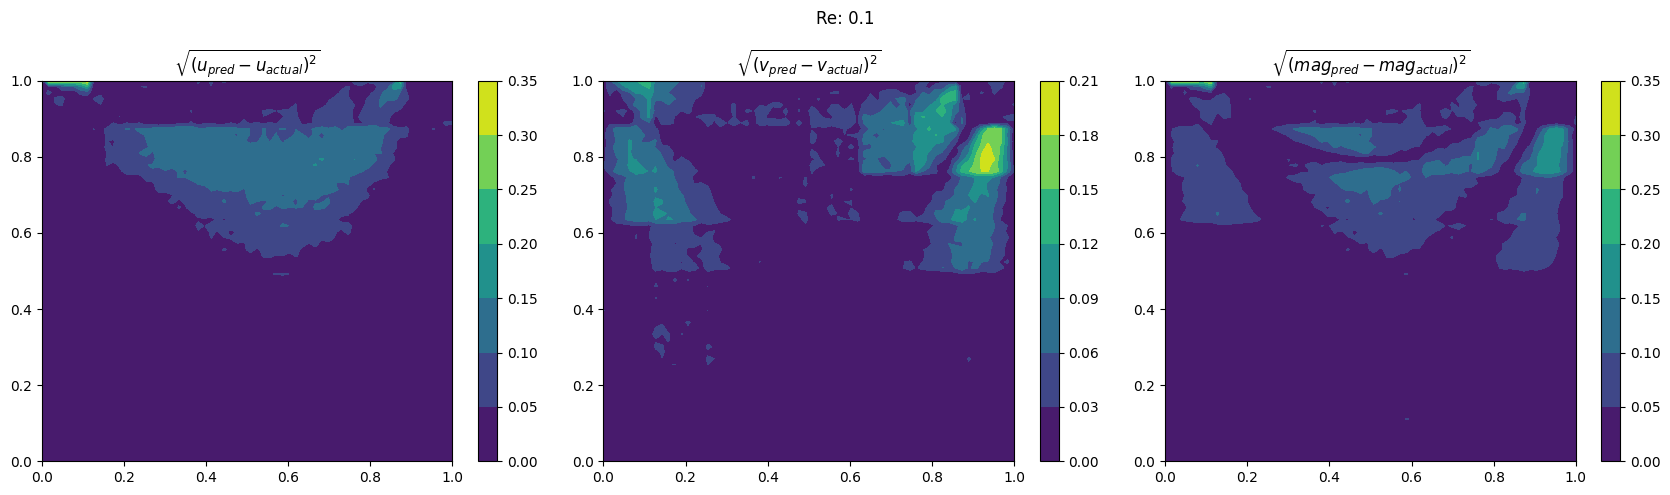

100%|██████████| 64/64 [00:00<00:00, 76.49it/s]


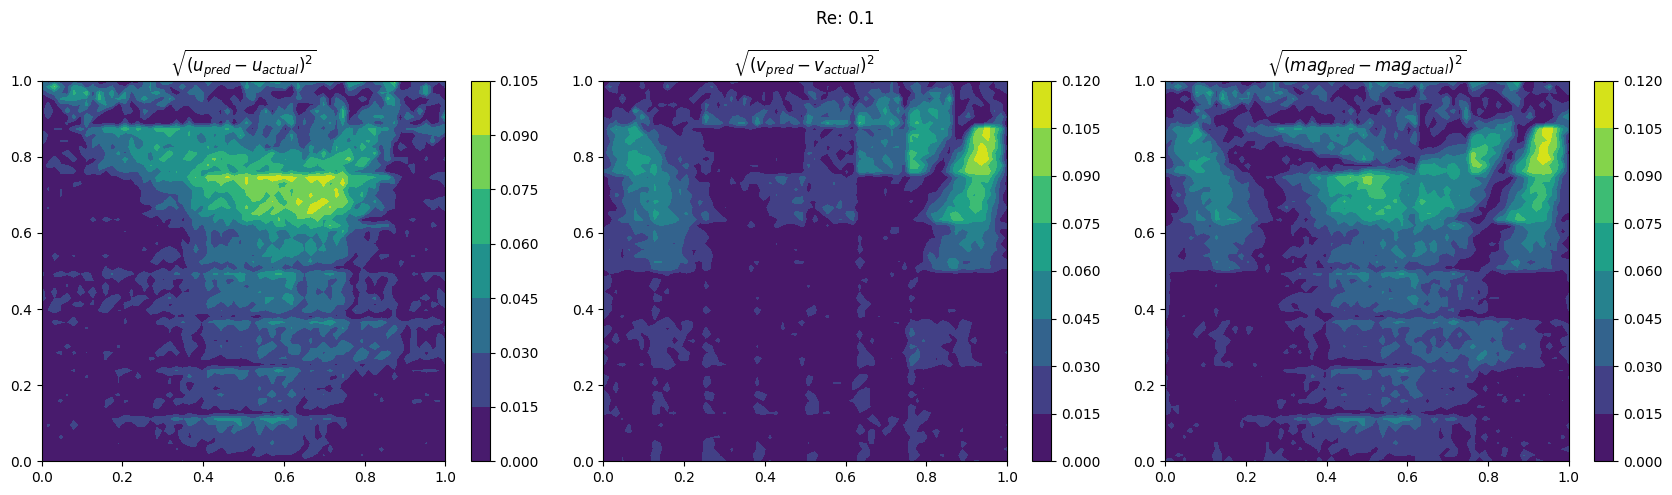

100%|██████████| 64/64 [00:00<00:00, 66.81it/s]


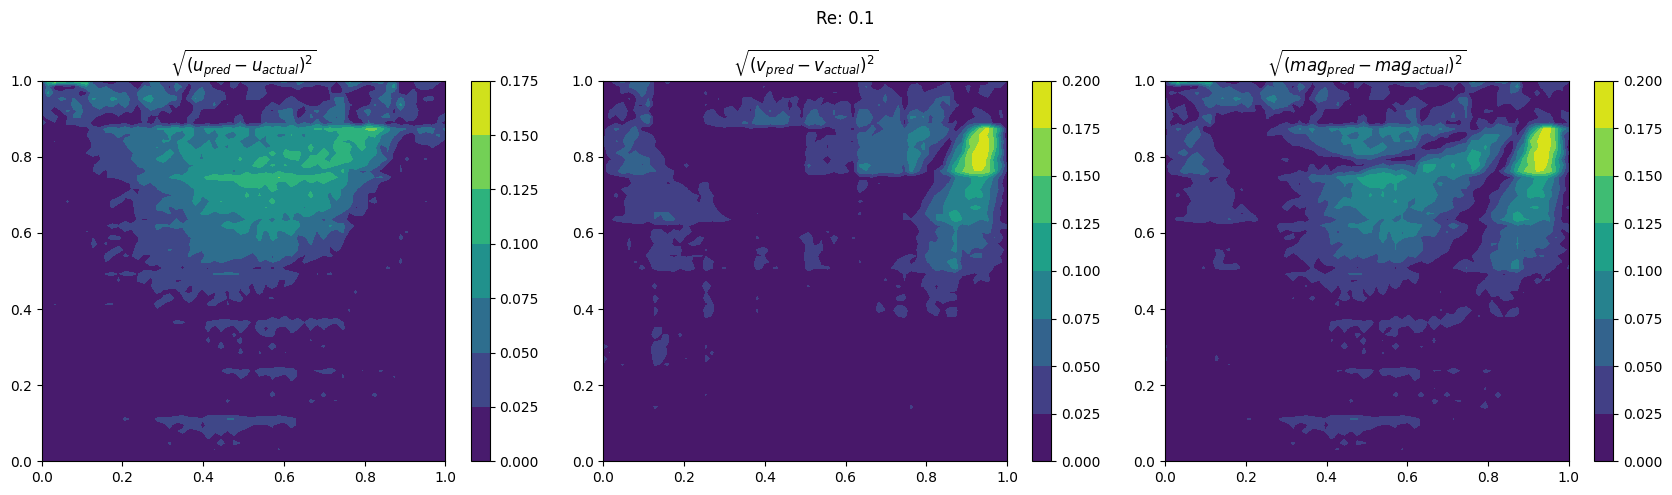

100%|██████████| 64/64 [00:00<00:00, 82.98it/s] 


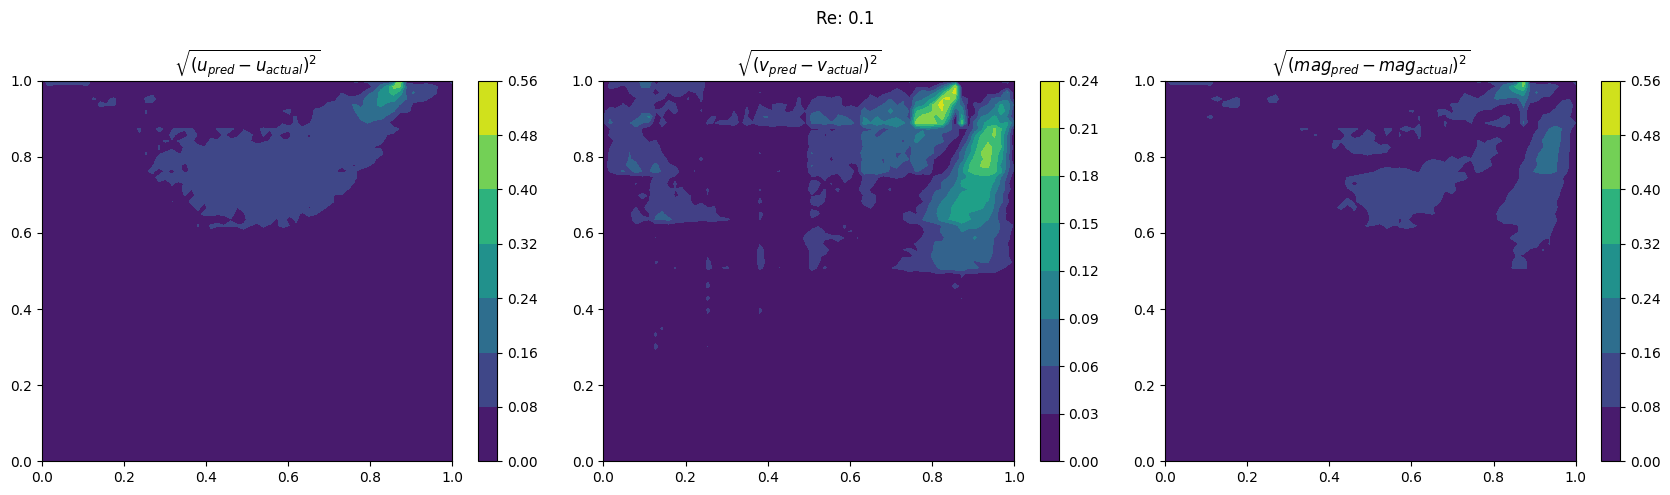

100%|██████████| 64/64 [00:00<00:00, 79.98it/s]


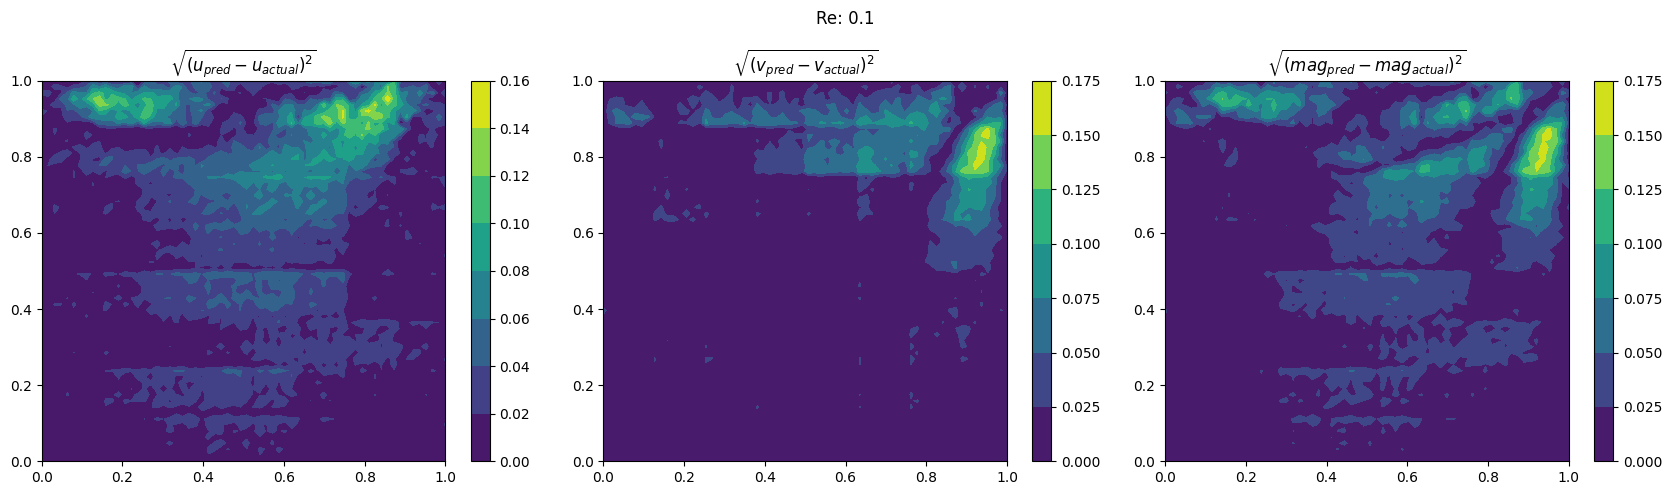

100%|██████████| 64/64 [00:00<00:00, 81.72it/s]


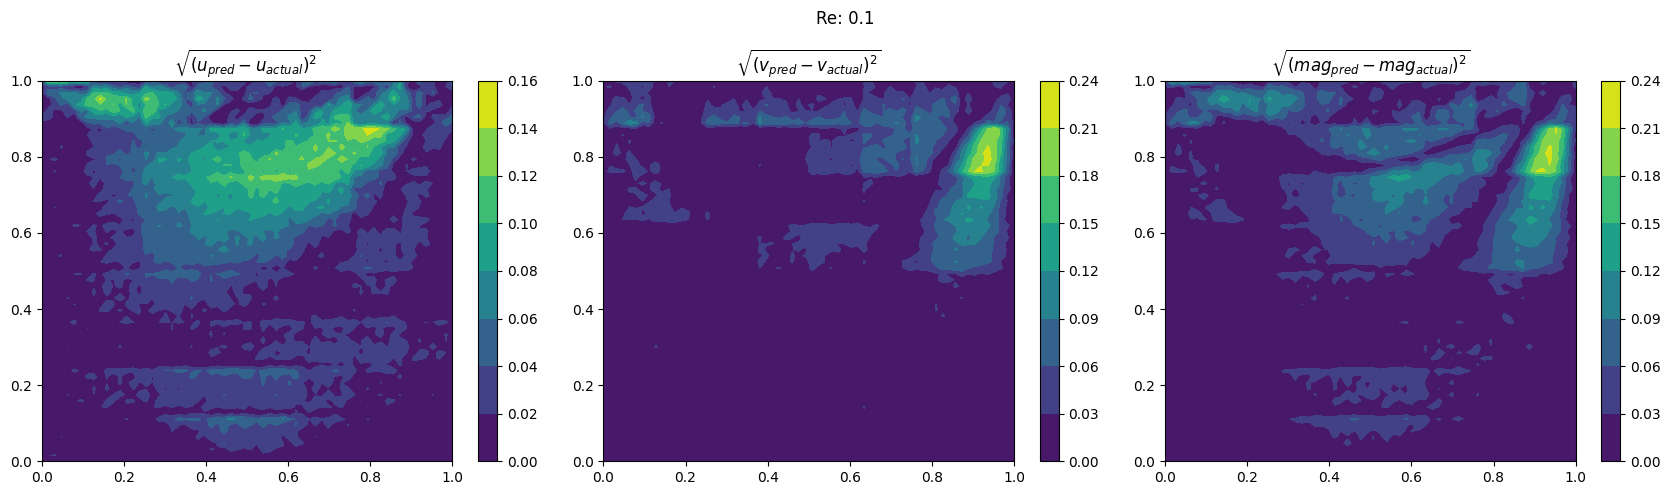

100%|██████████| 64/64 [00:00<00:00, 76.72it/s]


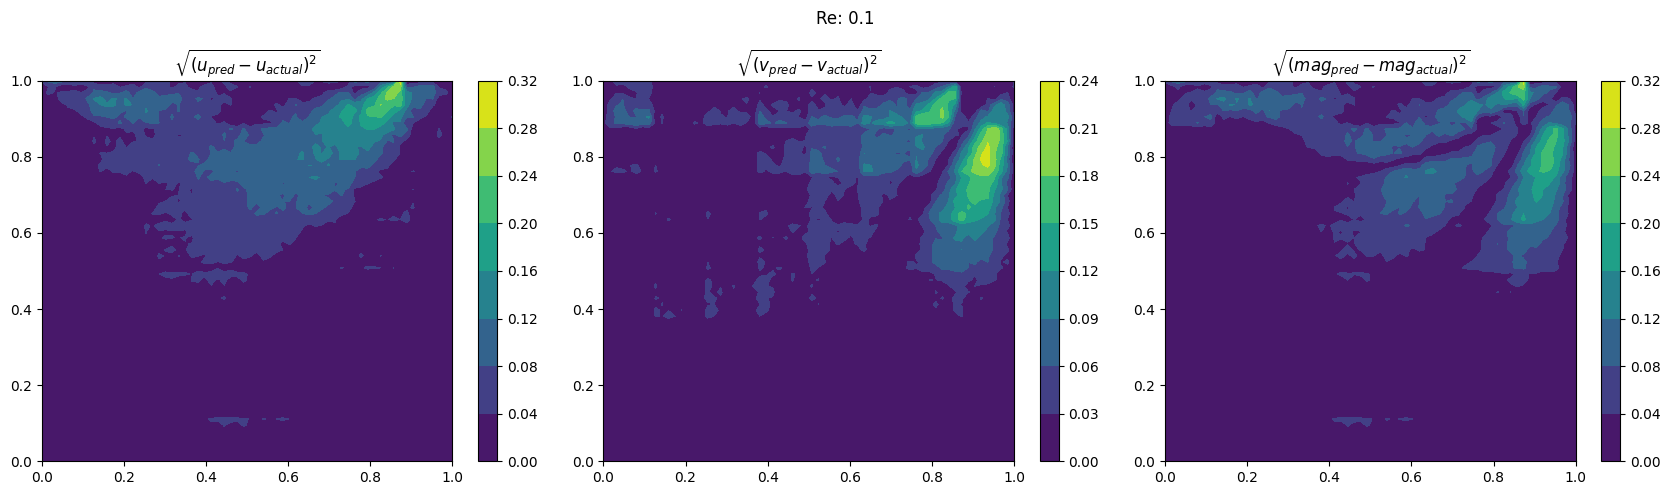

100%|██████████| 64/64 [00:00<00:00, 81.24it/s] 


KeyboardInterrupt: 

In [174]:
# errors = {}

for re_idx in range(len(pre_train_re)):

    err = {}

    u_grid_actual, v_grid_actual, div_actual, mag_actual = ground_truth(re = pre_train_re[re_idx], plot = False)

    u_grid_pred, v_grid_pred, div_pred, mag_pred = predict(re_value = pre_train_re[re_idx], model = transformer, 
                                                re_mean = RE_MEAN, re_std = RE_STD, u_mean = U_MEAN, u_std = U_STD, v_mean = V_MEAN, v_std = V_STD, 
                                                config = config, device = "cpu", plot = False)


    u_difference = torch.sqrt((torch.tensor(u_grid_actual) - u_grid_pred)**2)
    v_difference = torch.sqrt((torch.tensor(v_grid_actual) - v_grid_pred)**2)
    mag_difference = torch.sqrt((torch.tensor(mag_actual) - mag_pred)**2)

    err["u_error"] = u_difference.mean().item()
    err["v_error"] = v_difference.mean().item()
    err["mag_error"] = mag_difference.mean().item()
    err["isTrain"] =  True if post_train_re[re_idx] in train_test_re['train_re'] else False

    # errors[pre_train_re[re_idx]] = err

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    lin = torch.linspace(0,1,64)

    u_diff_cbar = axes[0].contourf(lin, lin, u_difference)
    plt.colorbar(u_diff_cbar, ax = axes[0])
    axes[0].set_title("$\sqrt{({u_{pred} - u_{actual})}^2}$")

    v_diff_cbar = axes[1].contourf(lin, lin, v_difference)
    plt.colorbar(v_diff_cbar, ax = axes[1])
    axes[1].set_title("$\sqrt{({v_{pred} - v_{actual})}^2}$")

    mag_diff_cbar = axes[2].contourf(lin, lin, mag_difference)
    plt.colorbar(mag_diff_cbar, ax = axes[2])
    axes[2].set_title("$\sqrt{({mag_{pred} - mag_{actual})}^2}$")

    plt.suptitle(f"Re: {re}")
    plt.tight_layout()
    plt.show()

    # break

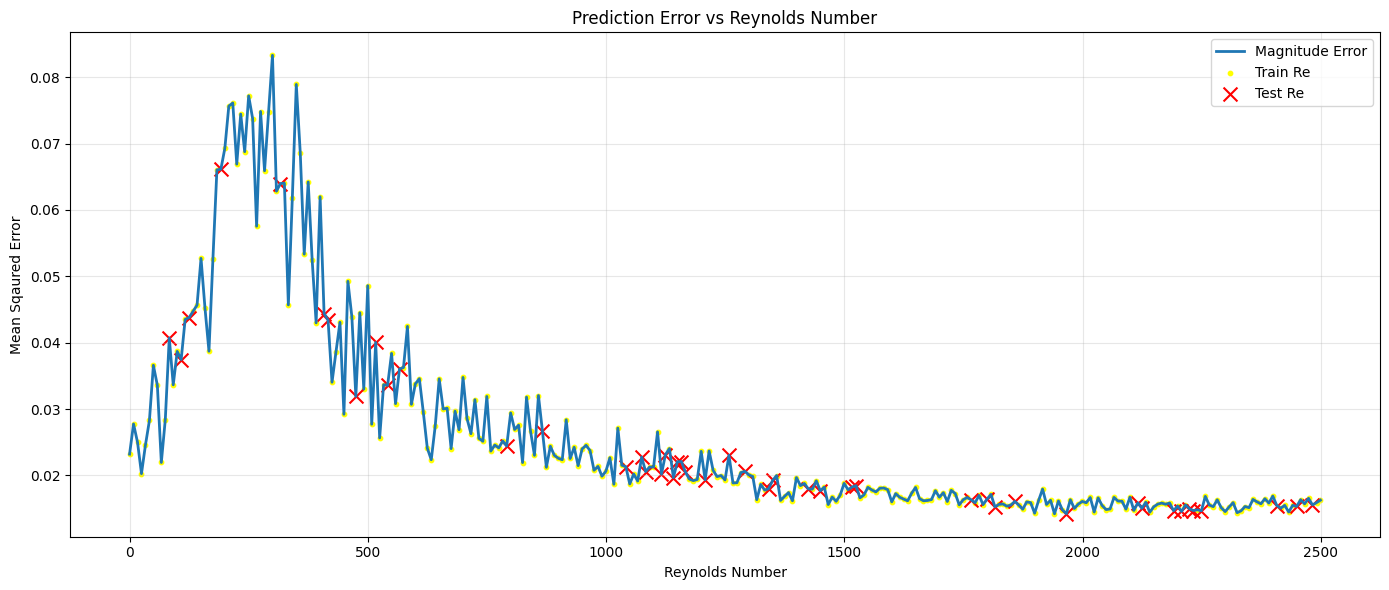

In [183]:
df = pd.DataFrame(errors).T.reset_index()
df = df.rename(columns={"index": "Re"})
df = df.sort_values("Re")

train_df = df[df["isTrain"]]
test_df  = df[df['isTrain'] == False]

plt.figure(figsize=(14, 6))

# Lines
# plt.plot(df["Re"], df["u_error"], label="U Error", linewidth=0.1)
# plt.plot(df["Re"], df["v_error"], label="V Error", linewidth=0.1)
plt.plot(df["Re"], df["mag_error"], label="Magnitude Error", linewidth=2)

# Train points
plt.scatter(
    train_df["Re"],
    train_df["mag_error"],
    marker="o",
    s=10,
    label="Train Re",
    color = "yellow"
)

# Test points
plt.scatter(
    test_df["Re"],
    test_df["mag_error"],
    marker="x",
    s=100,
    label="Test Re", color = "red",
)

plt.xlabel("Reynolds Number")
plt.ylabel("Mean Sqaured Error")
plt.title("Prediction Error vs Reynolds Number")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [192]:
max_mag_error = max(
    errors[re]["mag_error"]
    for re in errors
)

min_mag_error = 0.0
max_mag_error

0.08329862881167366

In [194]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import numpy as np

frames = []

for re in sorted(pre_train_re):

    u_gt, v_gt, div_gt, mag_gt = ground_truth(re=re, plot=False)

    u_pred, v_pred, div_pred, mag_pred = predict(
        re_value=re,
        model=transformer,
        re_mean=RE_MEAN,
        re_std=RE_STD,
        u_mean=U_MEAN,
        u_std=U_STD,
        v_mean=V_MEAN,
        v_std=V_STD,
        config=config,
        device="cpu",
        plot=False
    )

    mag_error = np.abs(torch.tensor(mag_gt) - mag_pred)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # -----------------------
    # Actual
    # -----------------------
    c0 = axes[0].contourf(
        mag_gt,
        levels=50,
        cmap="jet"
    )
    axes[0].set_title("|U| Actual")
    fig.colorbar(c0, ax=axes[0])

    # -----------------------
    # Prediction
    # -----------------------
    c1 = axes[1].contourf(
        mag_pred,
        levels=50,
        cmap="jet"
    )
    axes[1].set_title("|U| Predicted")
    fig.colorbar(c1, ax=axes[1])

    # -----------------------
    # Error
    # -----------------------
    c2 = axes[2].contourf(
        mag_error,
        levels=np.linspace(min_mag_error, max_mag_error, 50),
        cmap="hot"
    )
    axes[2].set_title(
        f"|U| Error\nMean={mag_error.mean():.4f}"
    )
    fig.colorbar(c2, ax=axes[2])

    plt.suptitle(f"Re = {re:.1f}", fontsize=16)
    plt.tight_layout()

    fig.canvas.draw()

    frame = np.asarray(fig.canvas.renderer.buffer_rgba())
    frames.append(frame)

    plt.close(fig)

imageio.mimsave(
    "velocity_magnitude_comparison.mp4",
    frames,
    fps=10
)

100%|██████████| 64/64 [00:00<00:00, 71.90it/s] 
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 500) to (1504, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [187]:
imageio.mimsave(
    "reynolds_sweep.mp4",
    frames,
    fps=5
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1000, 800) to (1008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [7]:
all = []

In [9]:
i = 0.1
end = 2500
skip = 8.33


# i = 80
# end = 500
# skip = 10

while i < end:
    all.append(round(i, 2))
    i += skip


In [12]:
all = sorted(all)

for i in all:
    print(i, end = " ")

0.1 8.43 16.76 25.09 33.42 41.75 50.08 58.41 66.74 75.07 80 83.4 90 91.73 100 100.06 108.39 110 116.72 120 125.05 130 133.38 140 141.71 150 150.04 158.37 160 166.7 170 175.03 180 183.36 190 191.69 200 200.02 208.35 210 216.68 220 225.01 230 233.34 240 241.67 250 250.0 258.33 260 266.66 270 274.99 280 283.32 290 291.65 299.98 300 308.31 310 316.64 320 324.97 330 333.3 340 341.63 349.96 350 358.29 360 366.62 370 374.95 380 383.28 390 391.61 399.94 400 408.27 410 416.6 420 424.93 430 433.26 440 441.59 449.92 450 458.25 460 466.58 470 474.91 480 483.24 490 491.57 499.9 508.23 516.56 524.89 533.22 541.55 549.88 558.21 566.54 574.87 583.2 591.53 599.86 608.19 616.52 624.85 633.18 641.51 649.84 658.17 666.5 674.83 683.16 691.49 699.82 708.15 716.48 724.81 733.14 741.47 749.8 758.13 766.46 774.79 783.12 791.45 799.78 808.11 816.44 824.77 833.1 841.43 849.76 858.09 866.42 874.75 883.08 891.41 899.74 908.07 916.4 924.73 933.06 941.39 949.72 958.05 966.38 974.71 983.04 991.37 999.7 1008.03 1016.3

(array([47., 56., 30., 29., 30., 30., 30., 30., 30., 31.]),
 array([1.0000e-01, 2.5000e+02, 4.9990e+02, 7.4980e+02, 9.9970e+02,
        1.2496e+03, 1.4995e+03, 1.7494e+03, 1.9993e+03, 2.2492e+03,
        2.4991e+03]),
 <BarContainer object of 10 artists>)

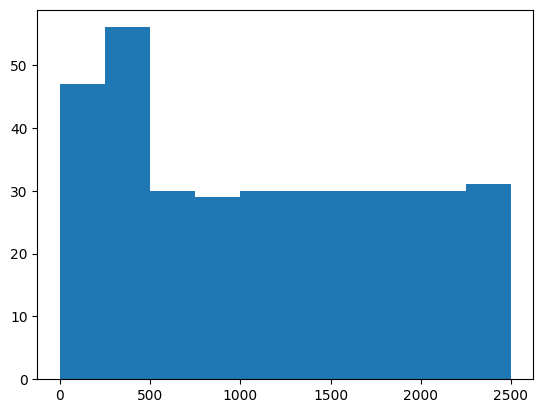

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(all)